# Ejercicio de programación - Regresión Logística

En este ejercicio se implementa la regresión logística para resolver un problema de clasificación binaria sobre un dataset de intrusiones de red (KDD Cup 99).

In [13]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
%matplotlib inline

## 1 Regresión Logística

En esta parte del ejercicio, creará un modelo de regresión logística para predecir si una conexión de red es normal o representa un ataque. Los datos contienen múltiples características que describen el tráfico de red simulado.

### 1.1 Visualización de los datos

Se cargan los datos y se realiza el preprocesamiento con Pandas para asegurar que las etiquetas sean binarias y las características categóricas se conviertan a numéricas.

In [14]:
data_path = '../Datasets/2_kddcup/kddcup.data_10_percent'
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 
    'dst_host_srv_rerror_rate', 'label'
]

df = pd.read_csv(data_path, header=None, names=columns)
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)

for col in ['protocol_type', 'service', 'flag']:
    df[col] = pd.factorize(df[col])[0]

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

m = y.size
indices = np.arange(m)
np.random.seed(42)
np.random.shuffle(indices)
X, y = X[indices], y[indices]

train_size = int(0.8 * m)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train, mu, sigma = featureNormalize(X_train)
X_test = (X_test - mu) / sigma

X_train = np.concatenate([np.ones((y_train.size, 1)), X_train], axis=1)
X_test = np.concatenate([np.ones((y_test.size, 1)), X_test], axis=1)

print(df.head())
print(f"X_train shape: {X_train.shape}")

   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0         0              0        0     0        181       5450     0   
1         0              0        0     0        239        486     0   
2         0              0        0     0        235       1337     0   
3         0              0        0     0        219       1337     0   
4         0              0        0     0        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   
2                     1.0                     0

### 1.2 Implementación

Antes de comenzar con el entrenamiento, se implementan las funciones clave del modelo.

#### 1.2.1 Función sigmoidea

La función sigmoidea se utiliza para mapear los resultados de la función lineal a un rango de probabilidad entre 0 y 1.

In [15]:
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    return g

#### 1.2.2 Función de costo y gradiente

La función de costo ayuda a evaluar la calidad de los parámetros theta actuales, mientras que el gradiente indica la dirección de la actualización.

In [16]:
def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    epsilon = 1e-15
    J = -(1/m) * (y.dot(np.log(h + epsilon)) + (1 - y).dot(np.log(1 - h + epsilon)))
    grad = (1/m) * (X.T.dot(h - y))
    return J, grad

def gradientDescent(X, y, theta, alpha, num_iters):
    m = y.size
    J_history = []
    for i in range(num_iters):
        J, grad = costFunction(theta, X, y)
        theta = theta - alpha * grad
        J_history.append(J)
    return theta, J_history

#### 1.2.3 Entrenamiento del modelo y gráfico de costo

Se entrena el modelo mediante el descenso por el gradiente y se visualiza la disminución del costo a lo largo de las iteraciones.

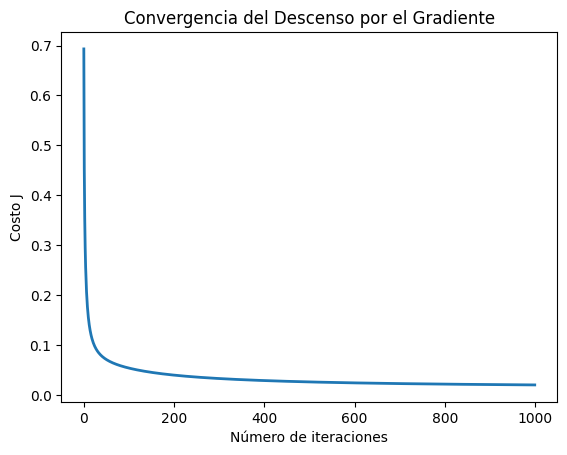

Costo final: 0.019916207606796313


In [17]:
alpha = 0.5
num_iters = 1000
theta = np.zeros(X_train.shape[1])

theta, J_history = gradientDescent(X_train, y_train, theta, alpha, num_iters)

pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.show()

print(f"Costo final: {J_history[-1]}")

### 1.3 Evaluación de la regresión logística

Finalmente, se comprueba el rendimiento del modelo utilizando el conjunto de prueba que no fue visto durante el entrenamiento.

In [18]:
def predict(theta, X):
    p = sigmoid(X.dot(theta)) >= 0.5
    return p.astype(int)

p = predict(theta, X_test)
accuracy = np.mean(p == y_test) * 100
print(f'Precisión en el conjunto de prueba: {accuracy:.2f} %')

for i in range(15):
    print(f"Predicción: {p[i]}, Real: {y_test[i]}")

Precisión en el conjunto de prueba: 99.55 %
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 0, Real: 0
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 1, Real: 1
Predicción: 0, Real: 0
Predicción: 1, Real: 1
